# 📘 Machine Learning: Linear Regression & Regression Metrics

## 📑 Table of Contents
1. [Introduction to Regression](#1-introduction-to-regression)
2. [Types of Linear Regression](#2-types-of-linear-regression)
3. [Simple Linear Regression (SLR) Intuition](#3-simple-linear-regression-slr-intuition)
4. [Finding Parameters: OLS vs Gradient Descent](#4-finding-parameters-ols-vs-gradient-descent)
5. [Regression Evaluation Metrics](#5-regression-evaluation-metrics)
6. [Comprehensive Code Implementations](#6-comprehensive-code-implementations)
7. [Assumptions of Linear Regression](#7-assumptions-of-linear-regression)
8. [Interview Questions & Key Takeaways](#8-interview-questions--key-takeaways)

---

## 1. Introduction to Regression



### What is Regression?
Regression is a supervised machine learning algorithm used to predict **continuous numerical values** based on the relationship between a dependent variable (target) and one or more independent variables (features).

| Problem Domain | Example | Output Type |
|----------------|---------|-------------|
| 🏠 Real Estate | House Price Prediction | ₹52,40,000 |
| 🌤️ Weather | Temperature Forecasting | 36.5°C |
| 💰 Finance | Stock Price Forecasting | USD 150.25 |
| 🏥 Healthcare | Medical Cost Prediction | USD 1,250.00|

### Why Linear Regression?


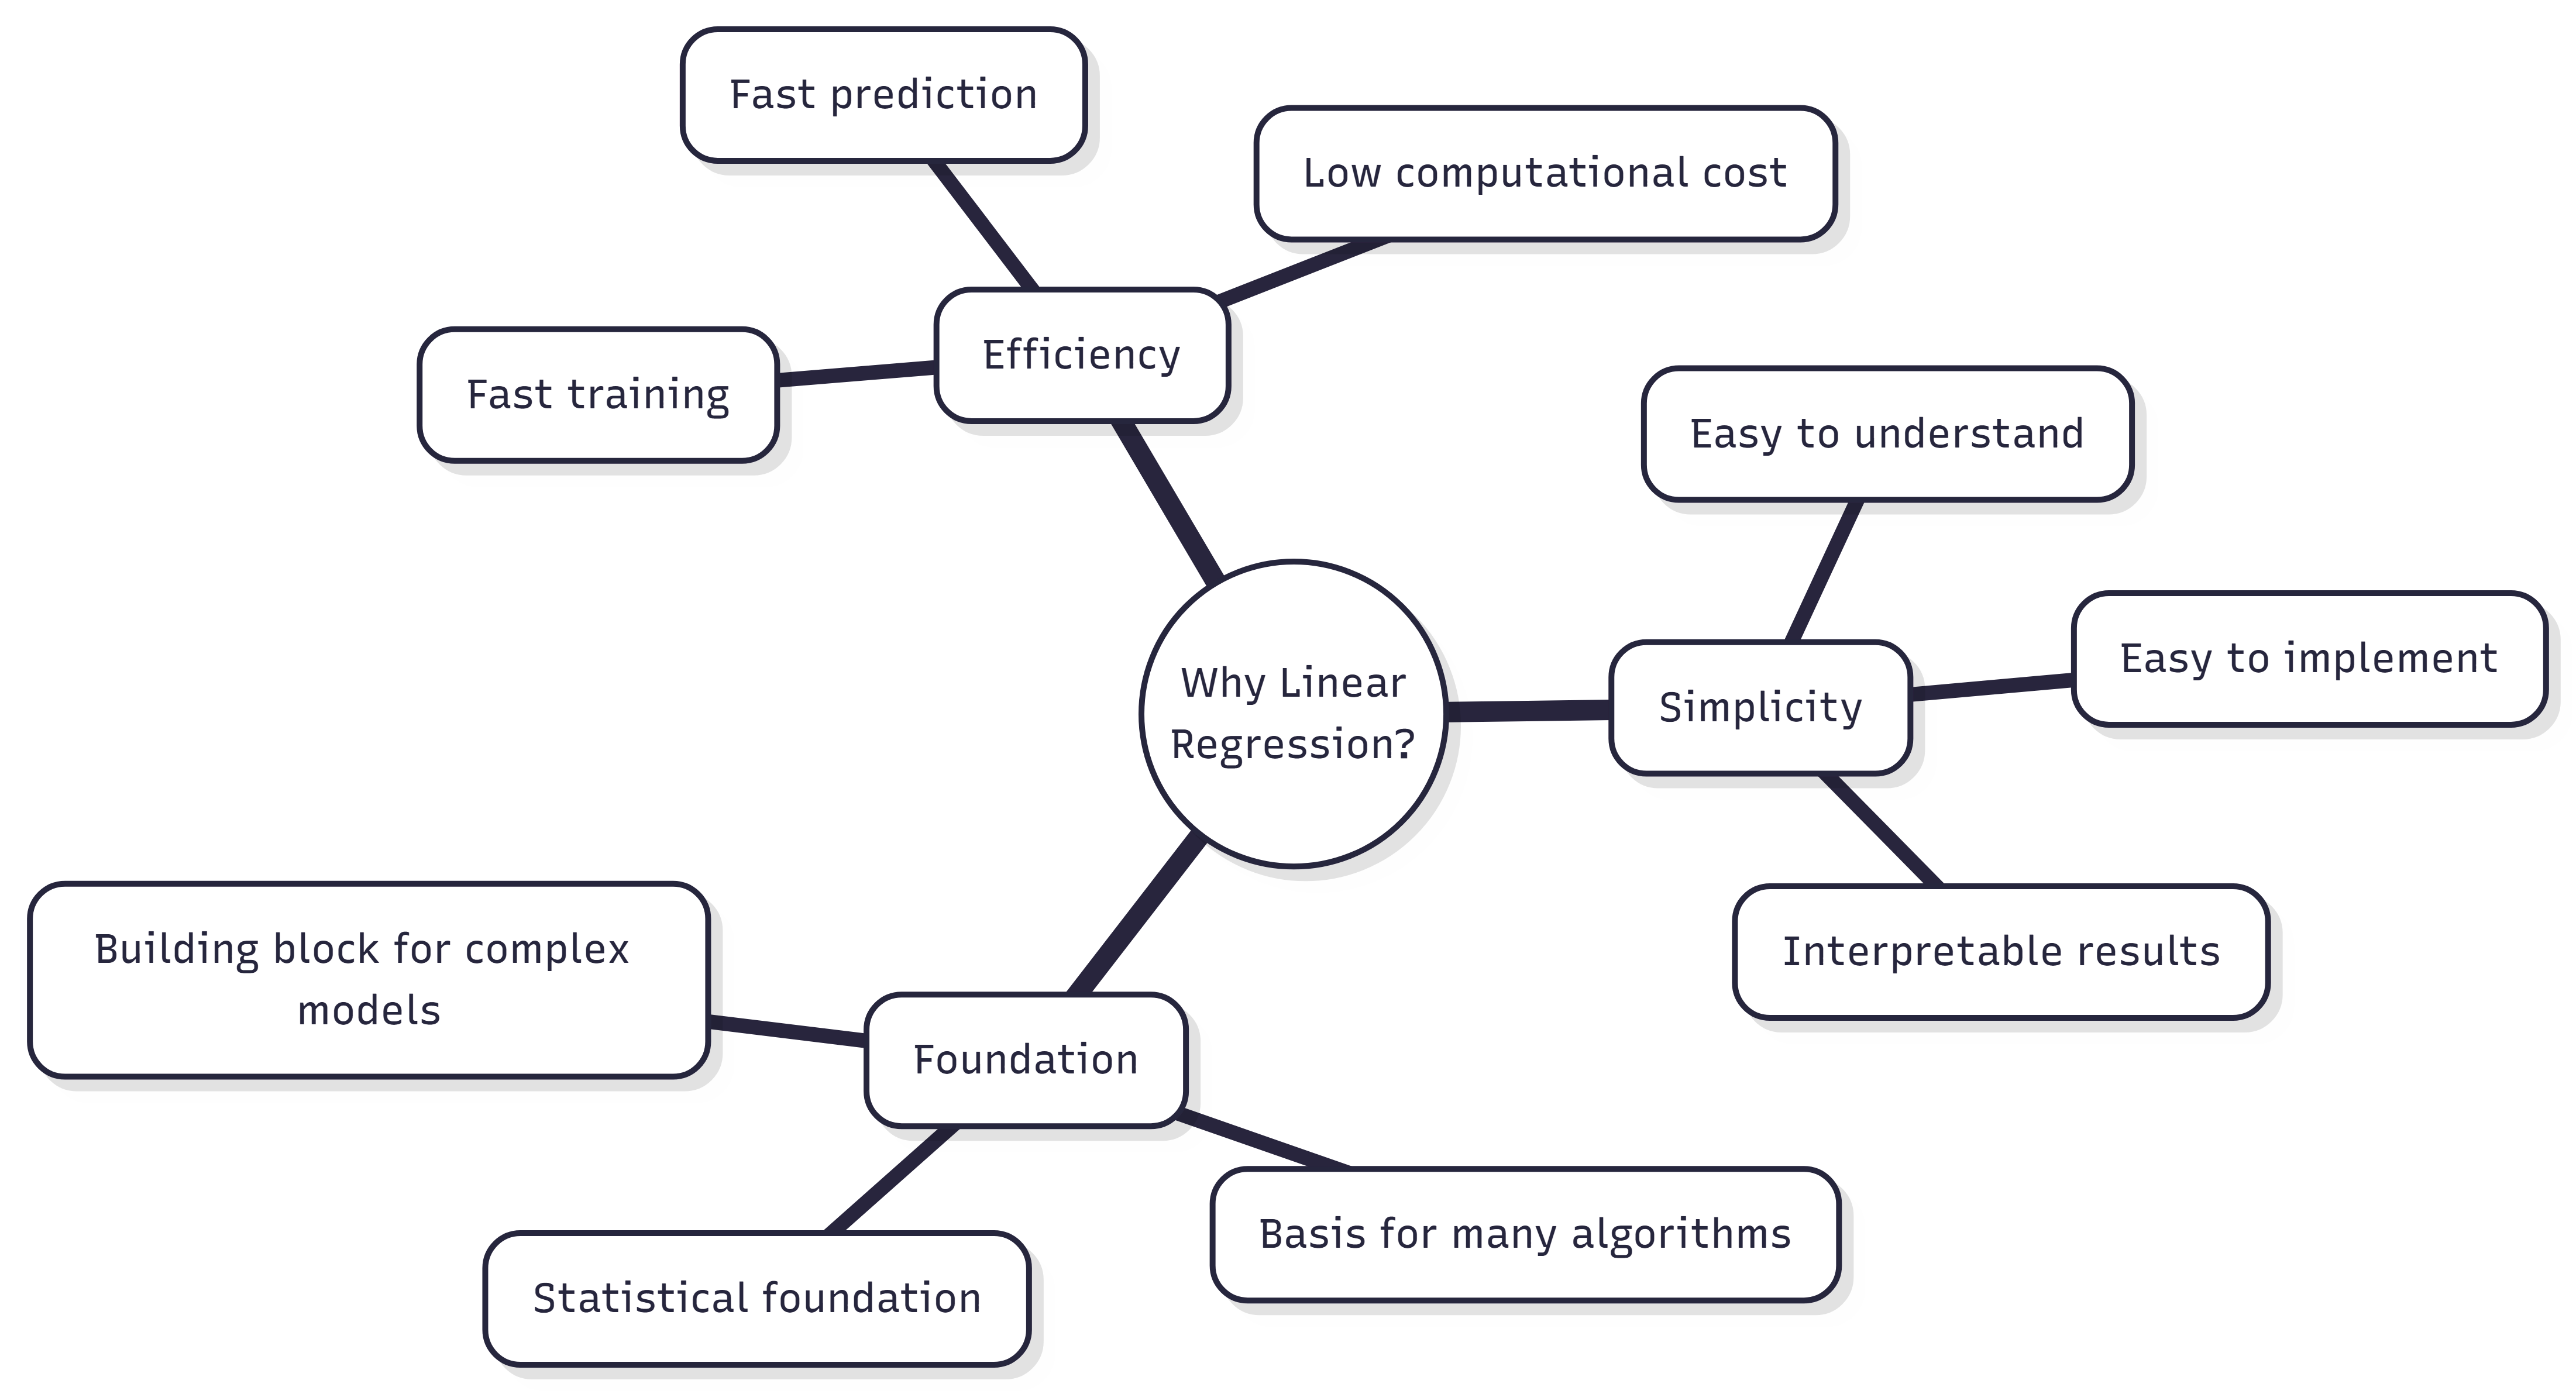

---

## 2. Types of Linear Regression


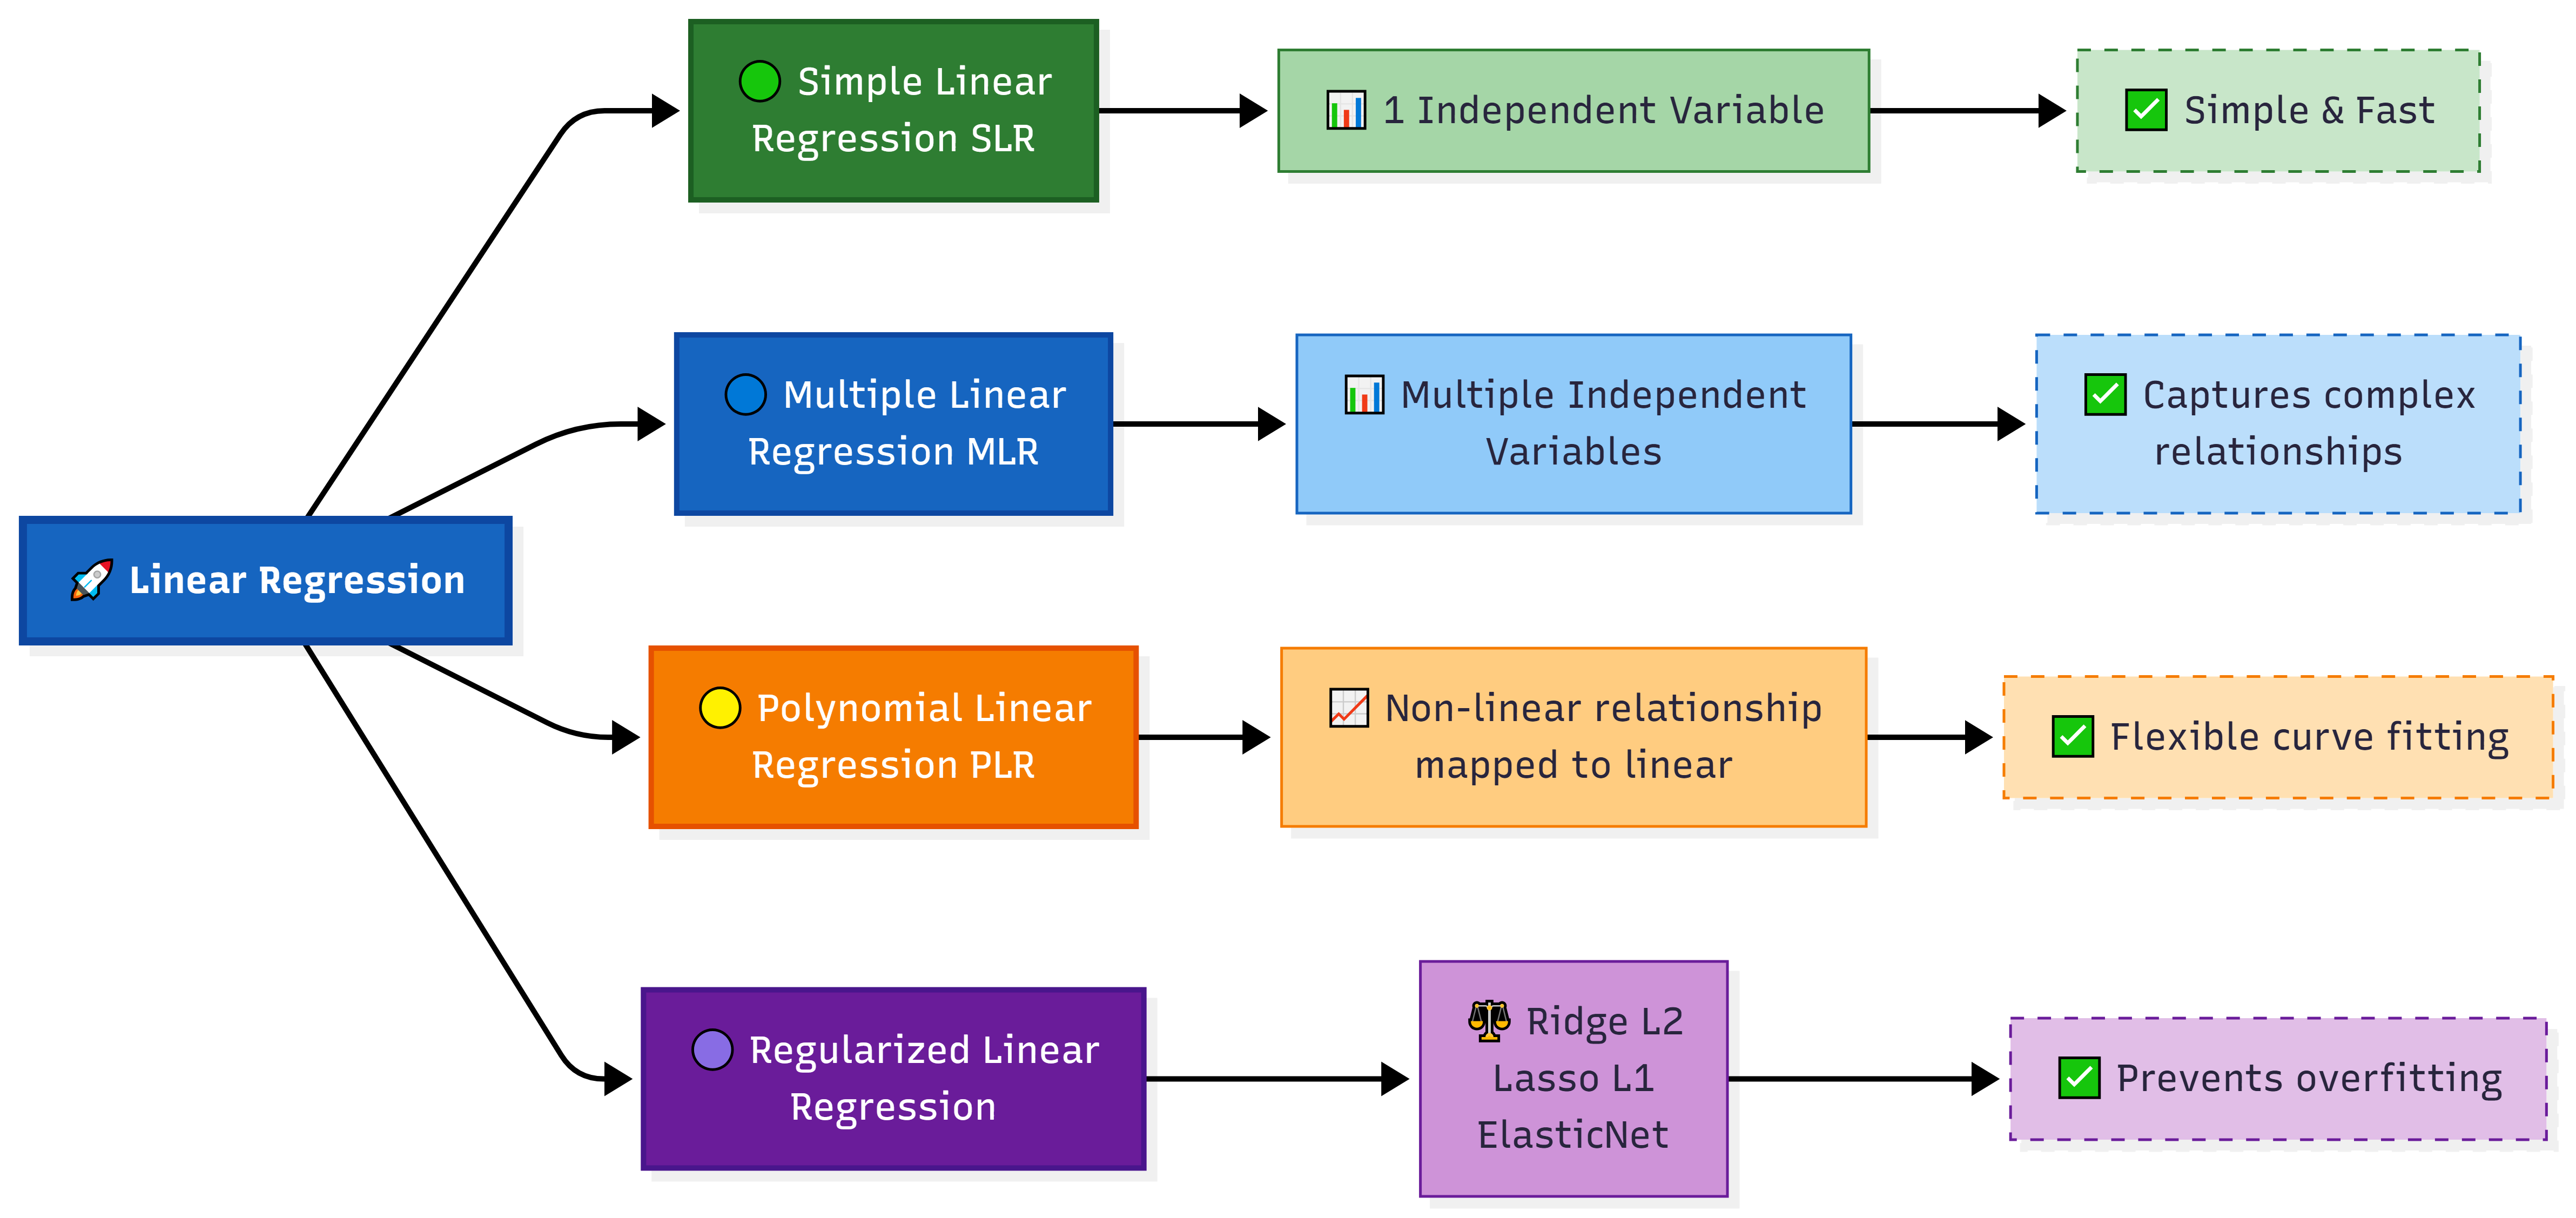

*   **Simple Linear Regression (SLR):** Uses exactly **one** independent variable to predict the target. (e.g., predicting house price based *only* on square footage).

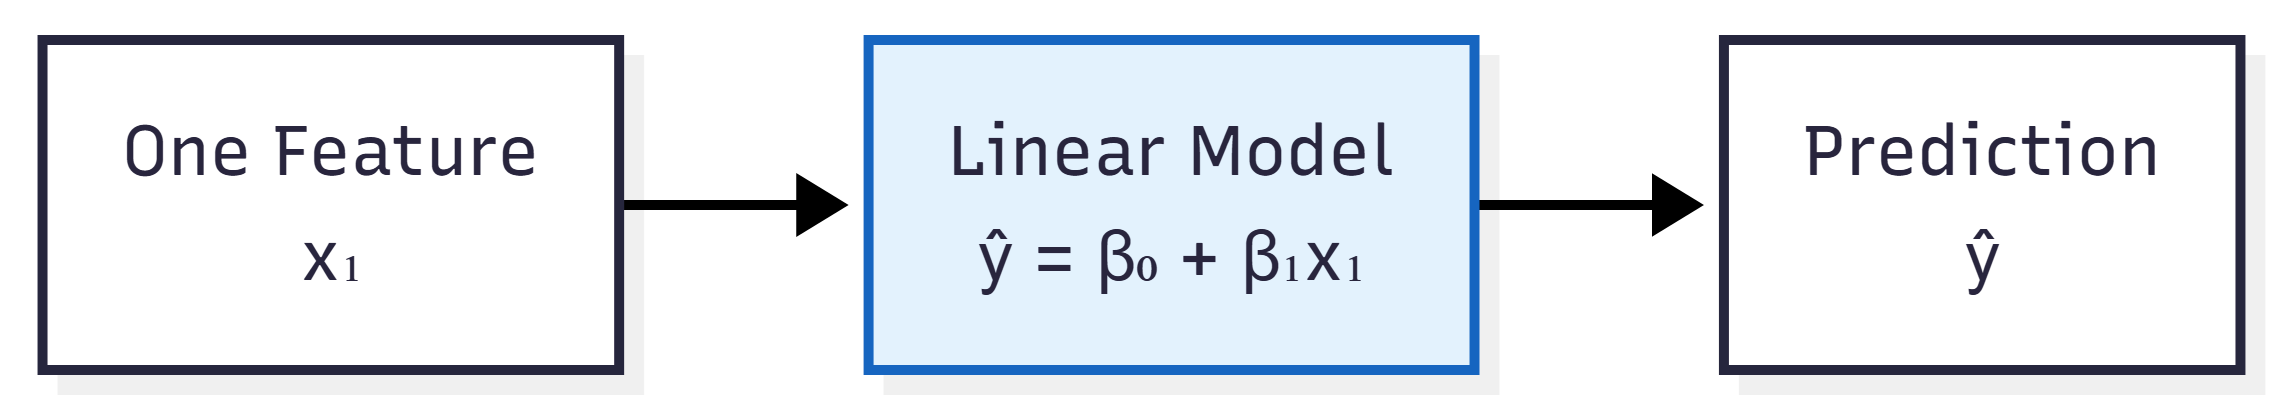

*   **Multiple Linear Regression (MLR):** Uses **two or more** independent variables. (e.g., predicting house price based on square footage, bedrooms, and location).

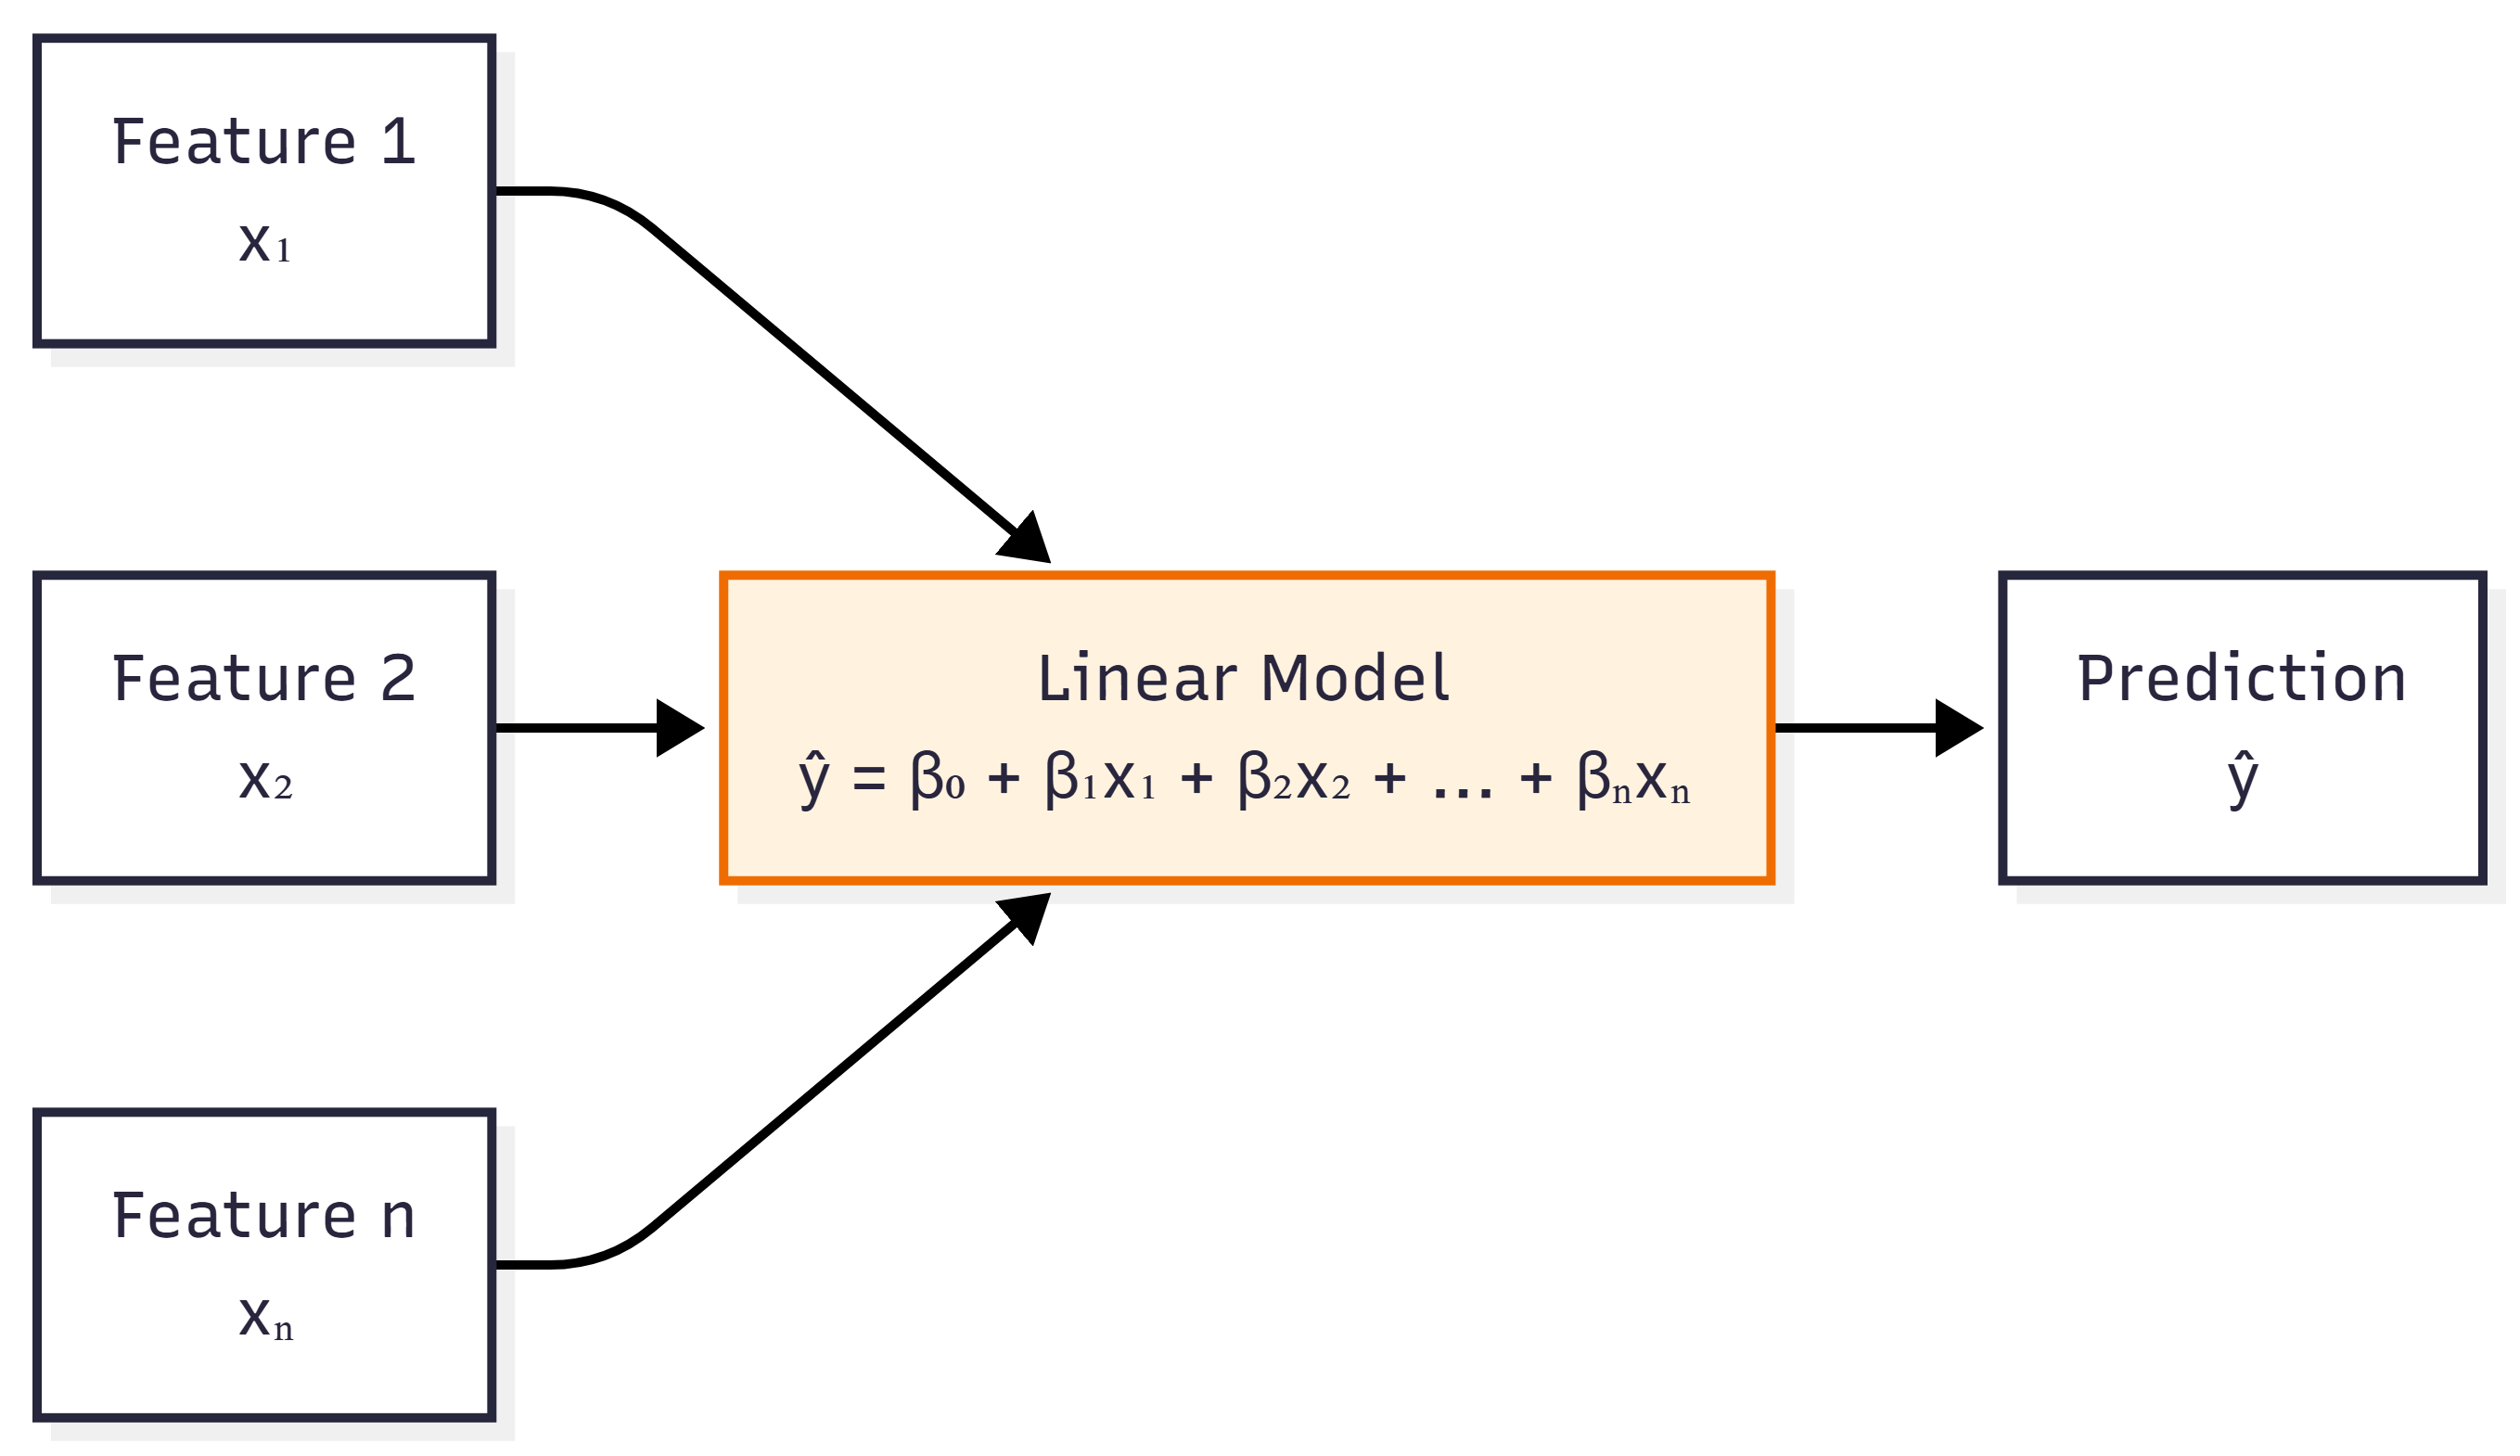




*   **Polynomial Linear Regression (PLR):** Used when the relationship is non-linear. We create polynomial features (e.g., $x^2, x^3$) and treat them as new independent variables in an MLR model.

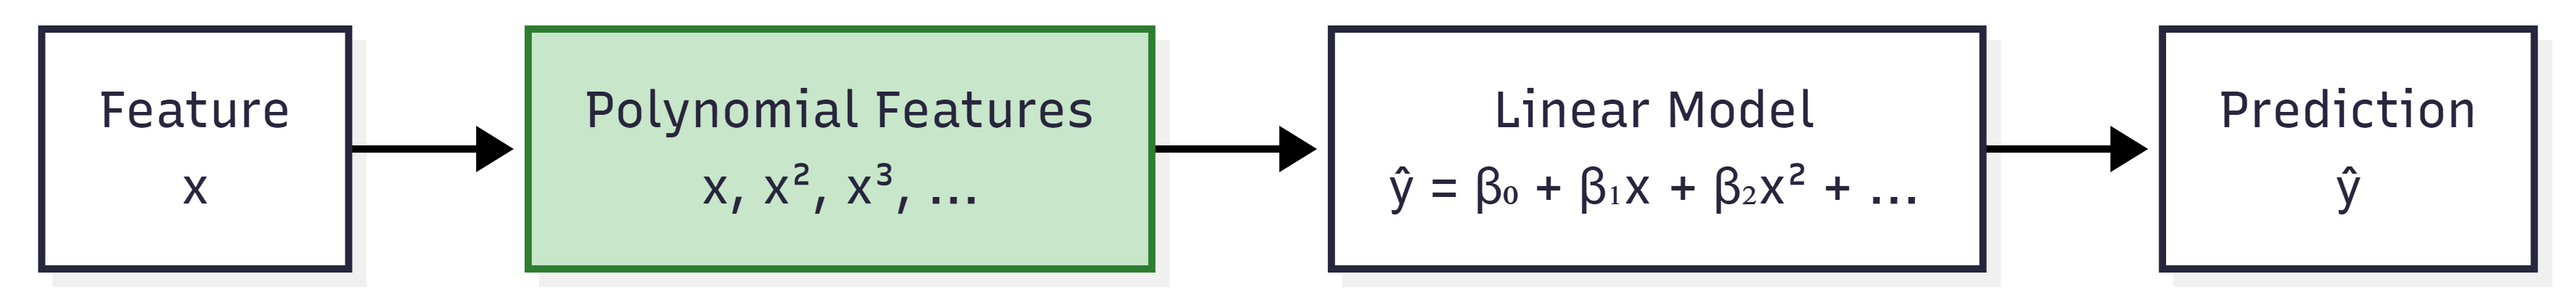

*   **Regularized Regression:** Techniques (Ridge, Lasso, ElasticNet) used to prevent overfitting in MLR by adding a penalty term to the loss function, shrinking the coefficients of less important features.
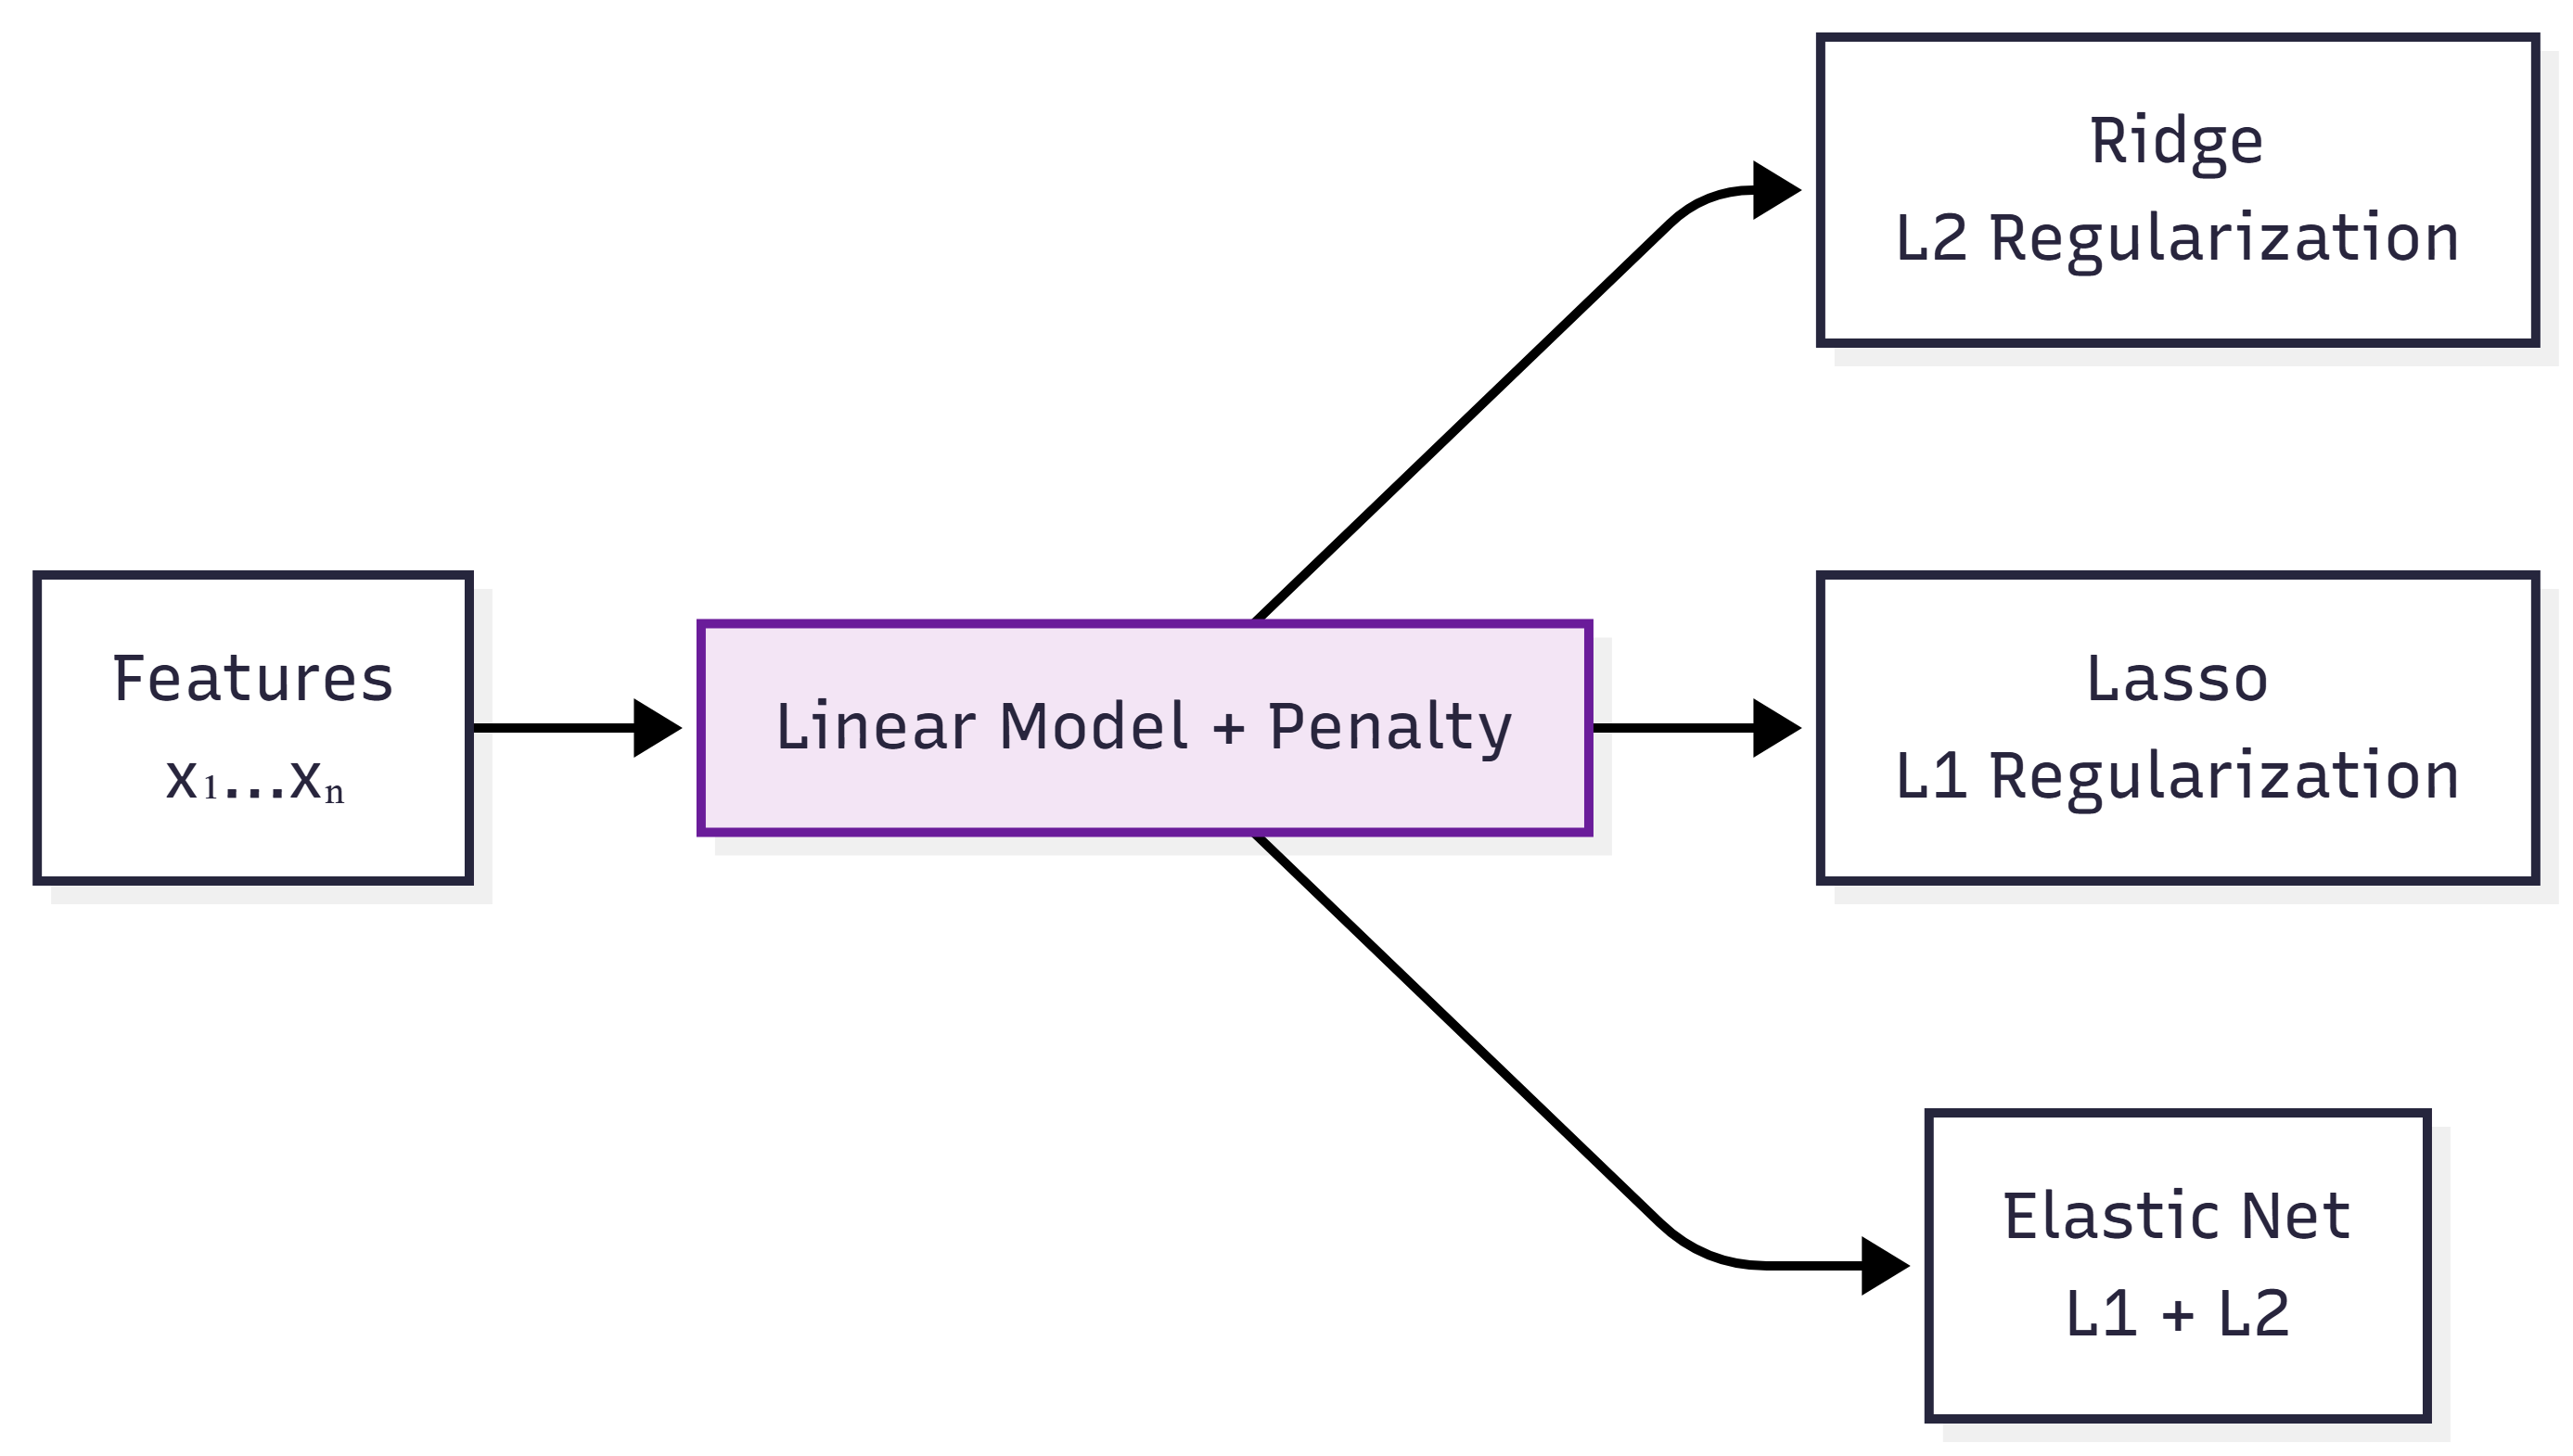
---

## 3. Simple Linear Regression (SLR) Intuition

### The Equation
The mathematical representation of a simple linear regression model is:

$$ \hat{y} = mx + b $$
*(or in statistical notation: $\hat{y} = \beta_0 + \beta_1 x$)*

Where:
*   $\hat{y}$ = Predicted value
*   $x$ = Independent variable (feature)
*   $m$ (or $\beta_1$) = **Slope / Weight / Coefficient** (How much $y$ changes for a 1-unit change in $x$)
*   $b$ (or $\beta_0$) = **Y-intercept / Bias** (The value of $y$ when $x = 0$)



---

## Intuition

The core intuition behind Linear Regression is finding the "Line of Best Fit." This line is positioned such that the overall distance (error) between the actual data points and the points predicted by the line is minimised.


###  How to find m and b?

For a Simple Linear Regression model, the equation of the line is:


$$y = mx + b$$


Where $m$ is the weight (slope) and $b$ is the bias (intercept). There are two primary ways to find these optimal parameters:

The goal of the algorithm is to find the optimal values for $m$ and $b$ such that the **Error (Residuals)** between the actual values ($y$) and predicted values ($\hat{y}$) is minimized.



In [2]:
# ============================================
# Simple Linear Regression - Complete Example
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
# ============================================
# 1. Create Synthetic Dataset
# ============================================
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature (0 to 10)
y = 3 * X.squeeze() + 5 + np.random.randn(100) * 2  # y = 3x + 5 + noise

# Convert to DataFrame
df = pd.DataFrame({
    'Feature': X.squeeze(),
    'Target': y
})

print("📊 Dataset Info:")
print(df.head(10))
print(f"\nDataset Shape: {df.shape}")
print(f"\nSummary Statistics:\n{df.describe()}")

📊 Dataset Info:
    Feature     Target
0  3.745401  16.410298
1  9.507143  32.923414
2  7.319939  27.143340
3  5.986585  18.984617
4  1.560186   9.241215
5  1.559945  10.394061
6  0.580836   9.698296
7  8.661761  29.948744
8  6.011150  21.416463
9  7.080726  25.238663

Dataset Shape: (100, 2)

Summary Statistics:
          Feature      Target
count  100.000000  100.000000
mean     4.701807   19.103262
std      2.974894    8.837473
min      0.055221    4.517970
25%      1.932008   11.572464
50%      4.641425   18.021013
75%      7.302031   27.029385
max      9.868869   36.170254


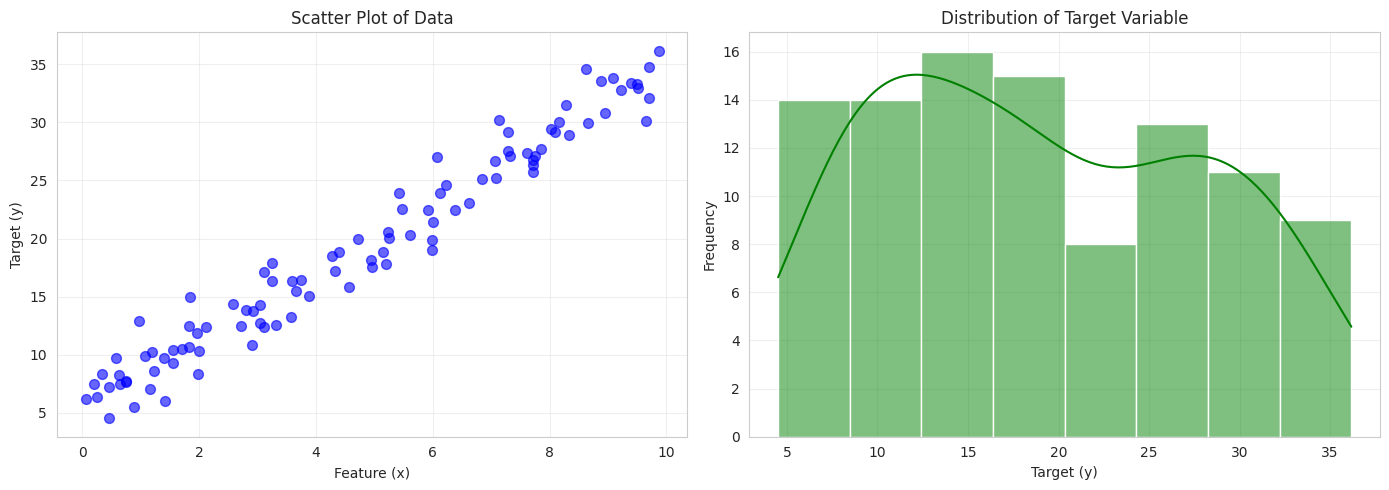

In [4]:
# ============================================
# 2. Visualize the Data
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(X, y, alpha=0.6, color='blue', s=50)
axes[0].set_xlabel('Feature (x)')
axes[0].set_ylabel('Target (y)')
axes[0].set_title('Scatter Plot of Data')
axes[0].grid(True, alpha=0.3)

# Distribution plots
sns.histplot(y, kde=True, ax=axes[1], color='green')
axes[1].set_xlabel('Target (y)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Target Variable')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ============================================
# 3. Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🔹 Training Set Size: {len(X_train)} samples")
print(f"🔹 Test Set Size: {len(X_test)} samples")
print(f"🔹 Training/Test Ratio: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")


🔹 Training Set Size: 80 samples
🔹 Test Set Size: 20 samples
🔹 Training/Test Ratio: 80.0% / 20.0%


In [6]:
# ============================================
# 4. Train the Model
# ============================================
model = LinearRegression()
model.fit(X_train, y_train)

# Extract parameters
m = model.coef_[0]
b = model.intercept_
print(f"\n📈 Model Parameters:")
print(f"  Slope (m): {m:.4f}")
print(f"  Intercept (b): {b:.4f}")
print(f"  Equation: y = {m:.4f}x + {b:.4f}")


📈 Model Parameters:
  Slope (m): 2.9197
  Intercept (b): 5.2858
  Equation: y = 2.9197x + 5.2858


In [7]:
# ============================================
# 5. Make Predictions
# ============================================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [8]:
# ============================================
# 6. Evaluate the Model
# ============================================
# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\n📊 Training Metrics:")
print(f"  MAE:  {train_mae:.4f}")
print(f"  MSE:  {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²:   {train_r2:.4f}")

print("\n📊 Testing Metrics:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")


📊 Training Metrics:
  MAE:  1.4695
  MSE:  3.3907
  RMSE: 1.8414
  R²:   0.9552

📊 Testing Metrics:
  MAE:  1.1827
  MSE:  2.6148
  RMSE: 1.6170
  R²:   0.9686


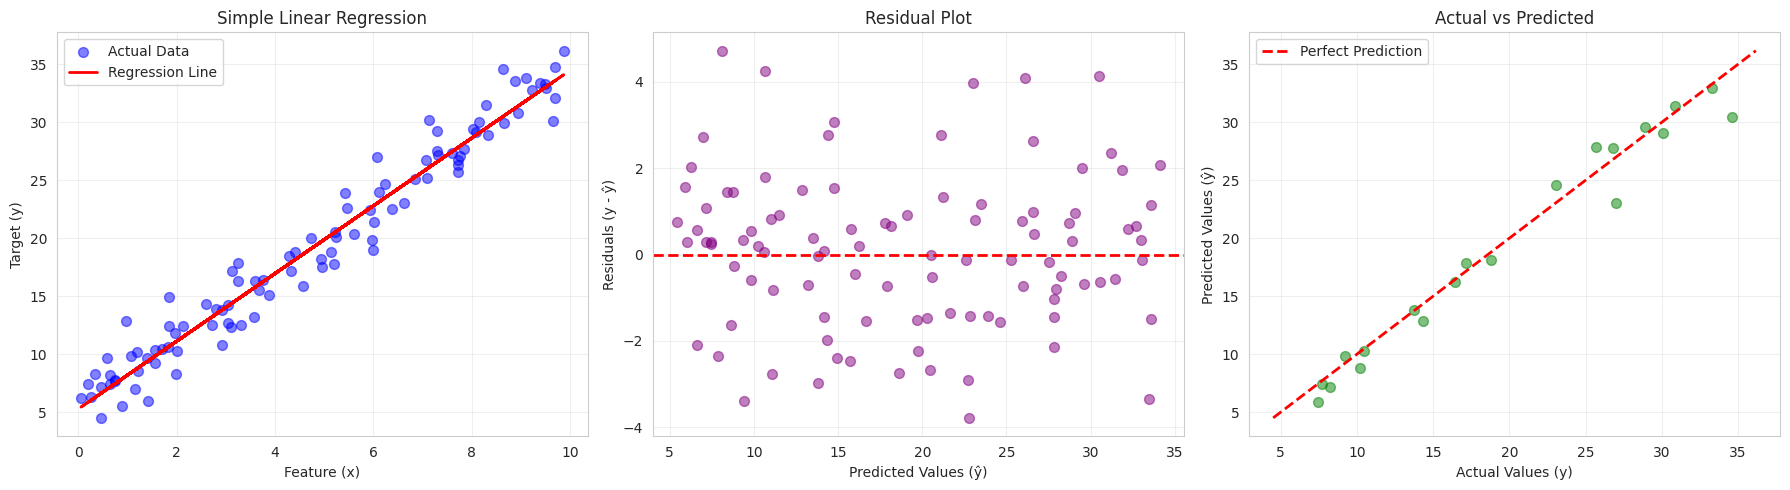

In [9]:
# ============================================
# 7. Visualize Results
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Regression Line
axes[0].scatter(X, y, alpha=0.5, color='blue', label='Actual Data', s=50)
axes[0].plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Feature (x)')
axes[0].set_ylabel('Target (y)')
axes[0].set_title('Simple Linear Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y - model.predict(X)
axes[1].scatter(model.predict(X), residuals, alpha=0.5, color='purple', s=50)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values (ŷ)')
axes[1].set_ylabel('Residuals (y - ŷ)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

# Plot 3: Actual vs Predicted
axes[2].scatter(y_test, y_test_pred, alpha=0.5, color='green', s=50)
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Values (y)')
axes[2].set_ylabel('Predicted Values (ŷ)')
axes[2].set_title('Actual vs Predicted')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# 8. Make Predictions on New Data
# ============================================
new_data = np.array([[2.5], [5.5], [8.0]])
predictions = model.predict(new_data)

print("\n🔮 Predictions on New Data:")
for x, y_pred in zip(new_data, predictions):
    print(f"  x = {x[0]:.1f} → ŷ = {y_pred:.2f}")


🔮 Predictions on New Data:
  x = 2.5 → ŷ = 12.59
  x = 5.5 → ŷ = 21.34
  x = 8.0 → ŷ = 28.64
